In [1]:
# LangGraph + LLM

!pip install langgraph langchain-openai langchain-core python-dotenv

In [2]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

open_api_key = os.getenv("OPENAI_API_KEY")
if not open_api_key:
    raise ValueError("OPENAI_API_KEY 설정 에러")

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)



In [10]:
# State
class QAState(TypedDict):    # total = False : 모든 키가 필수는 아님
  question:str
  answer:str
  summary:str

# node
def node_llm_answer(state:QAState) -> QAState:
  question = state['question']

  prompt = f"""
    너는 친절한 한국어 도우미야.
    아래 질문에 대해 10문장 이내로 설명해 줘,

    질문 :
    {question}
  """

  resp = llm.invoke(prompt)
  answer_text = resp.content
  print('LLM 답변 : ', answer_text)

  return {
      **state,
      'answer':answer_text
  }


def node_summarize_locally(state:QAState) -> QAState:
  # 원래는 LLM이 요약해야 하나 여기서는 그냥 앞 글자 일부만 잘라서 요약처럼 보이게 하기
  answer = state.get("answer", "")

  short = answer.strip().replace("\n", " ")
  if len(short) > 30:
    short = short[:30] + "..."

  summary = f"요약 내용 : {short}"

  return {
      **state,
      'summary':summary
  }




LLM 답변 :  양자 컴퓨팅은 기존 컴퓨터와 달리 양자 비트(큐비트)를 사용하는 새로운 컴퓨팅 방식이에요. 큐비트는 0과 1 상태를 동시에 가질 수 있는 중첩(superposition) 상태를 특징으로 해요. 이 덕분에 양자 컴퓨터는 복잡한 계산을 병렬로 빠르게 처리할 수 있죠. 또한, 얽힘(entanglement)이라는 현상으로 큐비트들 간에 강한 연관성을 만들어 계산 효율을 높여요. 이런 특성 때문에 암호 해독, 최적화 문제, 신약 개발 등에서 큰 잠재력을 가지고 있어요. 하지만 현재는 기술적 한계로 인해 상용화가 아직 초기 단계에 있어요. 양자 컴퓨팅은 미래의 혁신적인 기술로 기대받고 있답니다.

질문 :  양자 컴퓨팅에 대해 알고 싶어. 친절하게 설명해 줘

답변 :  양자 컴퓨팅은 기존 컴퓨터와 달리 양자 비트(큐비트)를 사용하는 새로운 컴퓨팅 방식이에요. 큐비트는 0과 1 상태를 동시에 가질 수 있는 중첩(superposition) 상태를 특징으로 해요. 이 덕분에 양자 컴퓨터는 복잡한 계산을 병렬로 빠르게 처리할 수 있죠. 또한, 얽힘(entanglement)이라는 현상으로 큐비트들 간에 강한 연관성을 만들어 계산 효율을 높여요. 이런 특성 때문에 암호 해독, 최적화 문제, 신약 개발 등에서 큰 잠재력을 가지고 있어요. 하지만 현재는 기술적 한계로 인해 상용화가 아직 초기 단계에 있어요. 양자 컴퓨팅은 미래의 혁신적인 기술로 기대받고 있답니다.

답변 요약 :  요약 내용 : 양자 컴퓨팅은 기존 컴퓨터와 달리 양자 비트(큐비트)를...


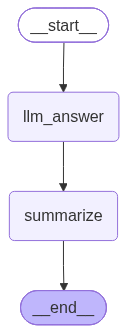

In [20]:
# graph 구성
def build_graph():
  graph = StateGraph(QAState)

  graph.add_node("llm_answer", node_llm_answer)
  graph.add_node("summarize", node_summarize_locally)

  graph.set_entry_point("llm_answer")

  graph.add_edge("llm_answer", "summarize")
  graph.add_edge("summarize", END)

  return graph.compile()

if __name__ == "__main__":
  app = build_graph()

  # 질문
  init_state: QAState = {
      "question" : "양자 컴퓨팅에 대해 알고 싶어. 친절하게 설명해 줘"
  }

  final_state = app.invoke(init_state)
  print('\n질문 : ', final_state['question'])
  print('\n답변 : ', final_state['answer'])
  print('\n답변 요약 : ', final_state['summary'])

  try:
    from IPython.display import Image, display
    graph_obj = app.get_graph()   # 내부 그래프 객체 얻기
    png_bytes = graph_obj.draw_mermaid_png()  # mermaid 기반 png 이미지 얻기
    display(Image(data=png_bytes))
  except Exception as e:
    print('Jupyter notebook 환경이 아니므로 그래프 출력 불가')
    print('에러 : ', e)

